# Election Analysis

## 1. Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import os
import urllib.request

In [2]:
font_path = "Kanit-Regular.ttf"

if not os.path.exists(font_path):
    print("Downloading Thai font (Kanit) for Matplotlib...")
    url = "https://raw.githubusercontent.com/google/fonts/main/ofl/kanit/Kanit-Regular.ttf"
    urllib.request.urlretrieve(url, font_path)
    print("✓ Download complete.")

THAI_FONT = fm.FontProperties(fname=font_path)
THAI_BOLD = fm.FontProperties(fname=font_path, weight="bold")
plt.rcParams["axes.unicode_minus"] = False
 
def th(s): return s  

In [3]:
C = {
    "เพื่อไทย":       "#E63946",
    "ภูมิใจไทย":      "#457B9D",
    "ประชาธิปัตย์":   "#2A9D8F",
    "ประชาชน":        "#F4A261",  
    "รวมไทยสร้างชาติ":"#8338EC",
    "พลังประชารัฐ":   "#6D6875",
    "other":          "#CED4DA",
}

MAJOR_PARTIES_PL = ["เพื่อไทย", "ภูมิใจไทย", "ประชาธิปัตย์", "ประชาชน", "รวมไทยสร้างชาติ", "พลังประชารัฐ"]

CANDIDATES = [
    "นายสุเกษม เรืองนุช",
    "นายเนียม ผลบุญ",
    "นายธเนส เครือรัตน์",
    "นายวีรชัย จันทร์ดวงศรี",
    "นายสิริพงศ์ อังคสกุลเกียรติ",
    "นายสุรเดช นาจำปา",
    "นายคณีศร คำโสภา",
    "นายกุลธวัช สาลี",
    "นางสาวฉวี ปิ่นทอม",
]

CAND_SHORT = {
    "นายสุเกษม เรืองนุช": "สุเกษม",
    "นายเนียม ผลบุญ": "เนียม",
    "นายธเนส เครือรัตน์": "ธเนส",
    "นายวีรชัย จันทร์ดวงศรี": "วีรชัย",
    "นายสิริพงศ์ อังคสกุลเกียรติ": "สิริพงศ์",
    "นายสุรเดช นาจำปา": "สุรเดช",
    "นายคณีศร คำโสภา": "คณีศร",
    "นายกุลธวัช สาลี": "กุลธวัช",
    "นางสาวฉวี ปิ่นทอม": "ฉวี",
}

---

## 2. Data Ingestion

In [4]:
# constituency (5/18) from เมือง and วังหิน
cu1 = pd.read_csv("data/constituency_units_edited.csv")
cu2 = pd.read_excel("data/วังหิน-validated/constituency-วังหิน-validated.xlsx")

cu2 = cu2.rename(columns={"ตำบลหน่วยเลือกตั้ง": "ตำบลหน่วยเลือกตั้ง"})
df_const = pd.concat([cu1, cu2], ignore_index=True) # concat them together
 
# party-list (5/18 บช) from เมือง and วังหิน
pl1 = pd.read_excel("data/party_list_by_unit_validated.xlsx") 
pl2 = pd.read_excel("data/วังหิน-validated/party-list-วังหิน-validated.xlsx")
df_party = pd.concat([pl1, pl2], ignore_index=True)
 
# Early voting constituency (5/16+5/17)
df_early_c = pd.read_csv("data/นอกเขต-validated/early_voting_constituency_validated.csv")
 
# Early voting party-list (5/16+5/17 บช)
df_early_p = pd.read_csv("data/นอกเขต-validated/early_voting_partylist_validated.csv")
 

## 3. Data Preprocessing

In [ ]:
# จำนวนผู้มาแสดงตน = จำนวนบัตรที่ใช้
null_showup = df_const["show_up"].isnull().sum()
print(f" Null show_up in constituency data: {null_showup} stations")
df_const["show_up"] = df_const["show_up"].fillna(df_const["used_cards"])
 
null_showup2 = df_party["show_up"].isnull().sum()
df_party["show_up"] = df_party["show_up"].fillna(df_party["used_cards"])
print(f" Null show_up in party-list data  : {null_showup2} stations → imputed")
 
# fully empty rows (eligible + used_cards both null) drop
before = len(df_const)
df_const = df_const.dropna(subset=["eligible"])
after = len(df_const)
print(f"  Dropped {before - after} fully-empty constituency rows")
 
before = len(df_party)
df_party = df_party.dropna(subset=["eligible"])
after = len(df_party)
print(f"Dropped {before - after} fully-empty party-list rows")
 
# Validate: candidate votes <= good_cards
df_const["candidate_total"] = df_const[CANDIDATES].sum(axis=1)
mismatch = (df_const["candidate_total"] > df_const["good_cards"] + 5).sum()
print(f"Constituency vote-sum anomalies   : {mismatch} stations")

 Null show_up in constituency data: 31 stations
 Null show_up in party-list data  : 11 stations → imputed
  Dropped 4 fully-empty constituency rows
  Dropped 3 fully-empty party-list rows
 Constituency vote-sum anomalies   : 0 stations


## 4. Feature Engineering

### 4.1 Turnout Rates & Proportional Vote Shares
We calculate the foundational metrics for each polling station: 
- the percentage of eligible voters who showed up (turnout) 
- the relative proportion of votes each candidate and major party received.

In [6]:
# Turnout rate 
df_const["turnout_rate"] = df_const["show_up"] / df_const["eligible"]
df_party["turnout_rate"] = df_party["show_up"] / df_party["eligible"]
 
# Candidate vote shares (election-day) --> calculate ratio
for c in CANDIDATES:
    df_const[c + "_share"] = df_const[c] / df_const["good_cards"].replace(0, np.nan)
 
# Party vote shares (election-day, focus on major parties)
pl_cols = [p for p in MAJOR_PARTIES_PL if p in df_party.columns]
for p in pl_cols: df_party[p + "_share"] = df_party[p] / df_party["good_cards"].replace(0, np.nan)

### 4.2 Station Winners & Competitive Margins
- Identify the winning candidate and party for every single polling station. 
- Calculate the "Margin of Victory" (1st vs 2nd place) to determine how competitive contested each unit was.

In [7]:
# Winner per station (constituency)
df_const["winner"] = df_const[CANDIDATES].idxmax(axis=1)
df_const["winner_votes"] = df_const[CANDIDATES].max(axis=1)
df_const["winner_share"] = df_const["winner_votes"] / df_const["good_cards"].replace(0, np.nan)
df_const["margin"] = (
    df_const["winner_votes"] - df_const[CANDIDATES].apply(lambda r: r.nlargest(2).iloc[-1], axis=1)
) / df_const["good_cards"].replace(0, np.nan)
 
# Winner per station (party-list)
df_party["pl_winner"] = df_party[pl_cols].idxmax(axis=1)

In [45]:
def get_margin_status(row):
    sorted_votes = sorted([row.get(c, 0) for c in CANDIDATES], reverse=True)
    if len(sorted_votes) >= 2 and row.get('good_cards', 0) > 0:
        margin = (sorted_votes[0] - sorted_votes[1]) / row['good_cards']
        if margin < 0.05: return "Battleground (<5%)"
        if margin < 0.15: return "Competitive (5-15%)"
        return "Safe (>15%)"
    return "Unknown"

df_const["competitiveness"] = df_const.apply(get_margin_status, axis=1)

### 4.3 Political Fragmentation (ENP)
**Effective Number of Parties (ENP)** index:  This metric measures the fragmentation of the vote. An ENP close to 1 means a monopoly (one candidate dominates), while a higher ENP indicates a highly competitive, multi-candidate battleground.

In [8]:
def enp(row):
    shares = np.array([row[c + "_share"] for c in CANDIDATES if not pd.isna(row.get(c + "_share", np.nan))])
    shares = shares[shares > 0]
    return 1 / (shares ** 2).sum() if shares.sum() > 0 else np.nan
 
df_const["ENP"] = df_const.apply(enp, axis=1)

### 4.4 Split-Ticket Voting Behavior (testing if chosen people == party?)
Finally, we merge the Constituency and Party-List datasets to detect "Split-Ticket" voting. We cross-reference the local candidate's party alignment with the party that won the national list at that exact same polling station.

In [ ]:
# Split-ticket: party-list winner vs constituency winner
# Map constituency winner → guessed party affiliation (based on known 2026 alignments)
WINNER_PARTY = {
    "นายสิริพงศ์ อังคสกุลเกียรติ": "ภูมิใจไทย",   
    "นายธเนส เครือรัตน์":          "เพื่อไทย",
    "นายสุเกษม เรืองนุช":          "ประชาชน",
    "นายวีรชัย จันทร์ดวงศรี":      "ประชาธิปัตย์",
    "นายสุรเดช นาจำปา":            "รวมไทยสร้างชาติ",
    "นายเนียม ผลบุญ":              "อิสระ",
    "นายคณีศร คำโสภา":             "อิสระ",
    "นายกุลธวัช สาลี":             "อิสระ",
    "นางสาวฉวี ปิ่นทอม":           "อิสระ",
}
df_const["winner_party"] = df_const["winner"].map(WINNER_PARTY)
 
# Merge party-list winner into constituency df on source_pdf
merge_cols = ["source_pdf", "pl_winner"] + [p + "_share" for p in pl_cols]
df_merged = df_const.merge(
    df_party[merge_cols],
    on="source_pdf", how="inner", suffixes=("", "_pl")
)
df_merged["split_ticket"] = df_merged["winner_party"] != df_merged["pl_winner"]
print(f"\n  Total matched stations (const+pl): {len(df_merged)}")
print(f"  Split-ticket stations             : {df_merged['split_ticket'].sum()} ({df_merged['split_ticket'].mean()*100:.1f}%)")


  Total matched stations (const+pl): 281
  Split-ticket stations             : 129 (45.9%)


---

## 5. Aggregate Election Summaries

### 5.1 Overall Voter & Ballot Statistics
First, we aggregate the macro-level metrics across the entire constituency to evaluate overall democratic participation, including total eligible voters, actual turnout, and the volume of invalid (spoiled) ballots.

In [10]:
# Constituency
total_eligible = df_const["eligible"].sum()
total_showup = df_const["show_up"].sum()
total_good = df_const["good_cards"].sum()
total_bad = df_const["bad_cards"].sum()
overall_turnout = total_showup / total_eligible

### 5.2 Candidate & Party Totals (Election Day + Early Voting)
Next, we calculate the total votes for each candidate and party. Critically, we must combine the Election Day voting (Form 5/18) with the Advance/Early Voting data (Forms 5/16 and 5/17) to ensure no votes are left behind in our final tallies.

In [11]:
cand_totals = df_const[CANDIDATES].sum().sort_values(ascending=False)
cand_shares = cand_totals / total_good
 
# Early voting totals
ev_total_good = df_early_c["good_cards"].sum()
ev_cand_totals = df_early_c[CANDIDATES].sum().sort_values(ascending=False)
ev_cand_shares = ev_cand_totals / ev_total_good
 
# Combined (election day + early voting)
all_cand_totals = cand_totals + ev_cand_totals
all_cand_shares = all_cand_totals / (total_good + ev_total_good)
 
# Party-list totals
pl_party_totals = df_party[pl_cols].sum().sort_values(ascending=False)
ev_pl_totals = df_early_p[[p for p in pl_cols if p in df_early_p.columns]].sum().sort_values(ascending=False)

### 5.3 Summary Output Report
Finally, we print a formatted text report of the aggregated results. This serves as a quick snapshot of the election outcome before we move into visual plotting.

In [52]:
print("\nConstituency Results")
print(f"Total eligible   : {total_eligible:,.0f}")
print(f"Total turnout    : {total_showup:,.0f}  ({overall_turnout:.1%})")
print(f"Good ballots     : {total_good:,.0f}")
print(f"Invalid ballots  : {total_bad:,.0f}  ({total_bad/total_showup:.1%} invalid rate)")

print("\nCandidate votes (election day):")
for c, v in cand_totals.items():
    print(f"{CAND_SHORT[c]:<12} {v:>6,}  ({cand_shares[c]:.1%})")

print(f"\nParty-list top 5 (election day):")
for p, v in pl_party_totals.head(5).items():
    print(f"{p:<20} {v:>6,}")


Constituency Results
Total eligible   : 131,029
Total turnout    : 89,492  (68.3%)
Good ballots     : 85,797
Invalid ballots  : 2,194  (2.5% invalid rate)

Candidate votes (election day):
สิริพงศ์     49,926.0  (58.2%)
ธเนส         23,797.0  (27.7%)
สุเกษม       9,943.0  (11.6%)
ฉวี           770.0  (0.9%)
วีรชัย        384.0  (0.4%)
คณีศร         349.0  (0.4%)
เนียม         297.0  (0.3%)
สุรเดช        175.0  (0.2%)
กุลธวัช       161.0  (0.2%)

Party-list top 5 (election day):
ภูมิใจไทย            27,955.0
เพื่อไทย             24,442.0
ประชาชน              17,505.0
ประชาธิปัตย์         1,367.0
รวมไทยสร้างชาติ       923.0


---

## 6. Visualizations

In [13]:
FONT_TITLE = {"fontproperties": THAI_BOLD, "fontsize": 13}
FONT_AX = {"fontproperties": THAI_FONT, "fontsize": 10}
FONT_TICK  = {"fontproperties": THAI_FONT, "fontsize": 9}
FONT_ANNO  = {"fontproperties": THAI_FONT, "fontsize": 8}
 
def set_thai_ticks(ax, axis="both"):
    if axis in ("x", "both"):
        for lbl in ax.get_xticklabels():
            lbl.set_fontproperties(THAI_FONT)
    if axis in ("y", "both"):
        for lbl in ax.get_yticklabels():
            lbl.set_fontproperties(THAI_FONT)

### 6.1 Constituency Analysis 
This section focuses on the local constituency MP battles (form 5/18), analyzing candidate performance, overall voter turnout, and ballot validity.

#### 6.1.1 Total Candidate Votes (Election Day + Advance Voting)

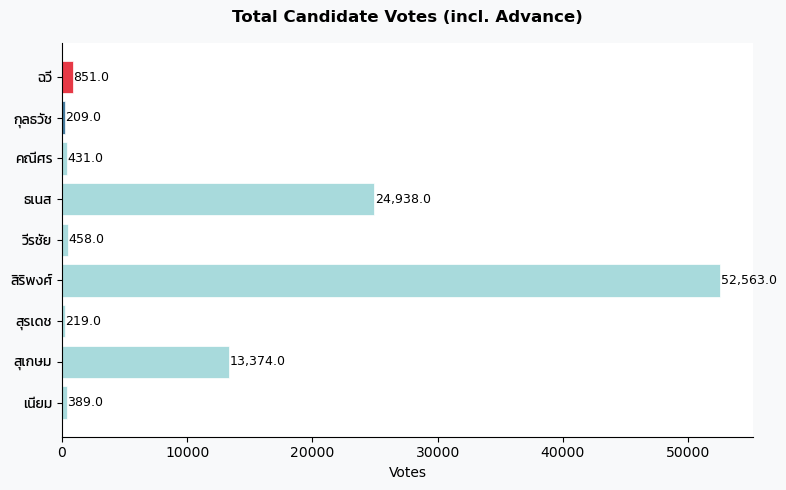

In [14]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="#F8F9FA")

names_short = [CAND_SHORT[c] for c in all_cand_totals.index]
colors_bar = ["#E63946" if i == 0 else "#457B9D" if i == 1 else "#A8DADC" for i in range(len(names_short))]

bars = ax.barh(names_short[::-1], all_cand_totals.values[::-1], color=colors_bar[::-1], edgecolor="white", linewidth=0.5)

# label
for bar, val in zip(bars, all_cand_totals.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=9)

ax.set_title("Total Candidate Votes (incl. Advance)", fontweight="bold", fontsize=12, pad=15)
ax.set_xlabel("Votes", fontsize=10)
ax.set_yticks(range(len(names_short)))

if 'THAI_FONT' in globals():
    ax.set_yticklabels(names_short[::-1], fontproperties=THAI_FONT, fontsize=10) 
else:
    ax.set_yticklabels(names_short[::-1], fontsize=10)

ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Insights:** 
- **สิริพงศ์ (ภูมิใจไทย)** obtained a landslide victory, dominating almost entire constituency. **ธเนส(เพื่อไทย)** is the only real competitor (2nd) --> This is a near-uncontested seat, not a competitive race.

#### 6.1.2 Election Day vs. Advance Voting Comparison

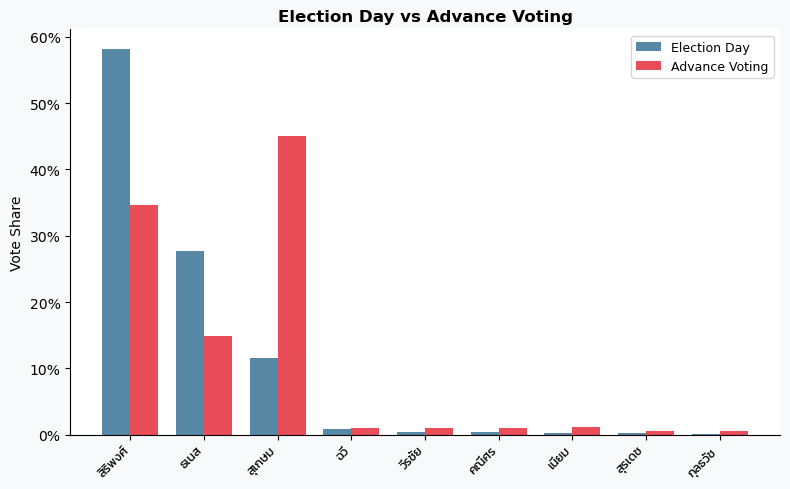

In [15]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="#F8F9FA")
x = np.arange(len(CANDIDATES))
w = 0.38
ed_shares_sorted = [cand_shares[c] for c in cand_totals.index]
ev_shares_sorted = [ev_cand_shares.get(c, 0) for c in cand_totals.index]

b1 = ax.bar(x - w/2, ed_shares_sorted, w, label="Election Day", color="#457B9D", alpha=0.9)
b2 = ax.bar(x + w/2, ev_shares_sorted, w, label="Advance Voting", color="#E63946", alpha=0.9)

ax.set_title("Election Day vs Advance Voting", fontweight="bold", fontsize=12)
ax.set_ylabel("Vote Share", fontsize=10)
ax.set_xticks(x)

ax.set_xticklabels([CAND_SHORT[c] for c in cand_totals.index], rotation=45, ha="right", fontproperties=THAI_FONT, fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** 
- สิริพงศ์ dropped from ~58% on election day to ~35% in advance voting, while สุเกษม jumped from ~15% to ~45% among advance voters
- สุเกษม may have had stronger organised mobilisation of advance voters
- Advance voting in Thailand skews toward certain demographic groups --> cross-reference with subdistricts that have high advance voter counts

#### 6.1.3 Voter Turnout & Invalid Ballot Rates by ตำบล

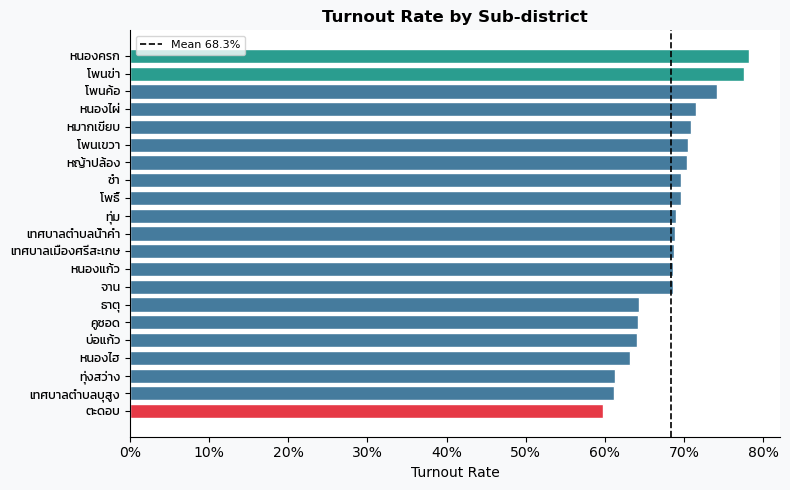

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="#F8F9FA")
tambon_turnout = df_const.groupby("ตำบลหน่วยเลือกตั้ง").apply(
    lambda g: g["show_up"].sum() / g["eligible"].sum()
).sort_values(ascending=True)

colors_t = ["#E63946" if v < 0.6 else "#457B9D" if v < 0.75 else "#2A9D8F" for v in tambon_turnout.values]
ax.barh(range(len(tambon_turnout)), tambon_turnout.values, color=colors_t, edgecolor="white")

ax.axvline(overall_turnout, color="black", linestyle="--", linewidth=1.2, label=f"Mean {overall_turnout:.1%}")
ax.set_title("Turnout Rate by Sub-district", fontweight="bold", fontsize=12)
ax.set_xlabel("Turnout Rate", fontsize=10)
ax.set_yticks(range(len(tambon_turnout)))

ax.set_yticklabels(tambon_turnout.index.tolist(), fontproperties=THAI_FONT, fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** 
- Turnout is geographically structured, not random
- The range is roughly 60% (ตะดอบ) to 78% (หนองครก) --> an 18 percentage point spread across subdistricts. 
- หนองครก and โพนข่า sit well above the 68.3% mean, while ตะดอบ lowest

**Key questions:** Does high turnout correlate with stronger สิริพงศ์ support? (implying that ground campaign of candidate drove turnout)

#### 6.1.4 Invalid ballot rate by ตำบล

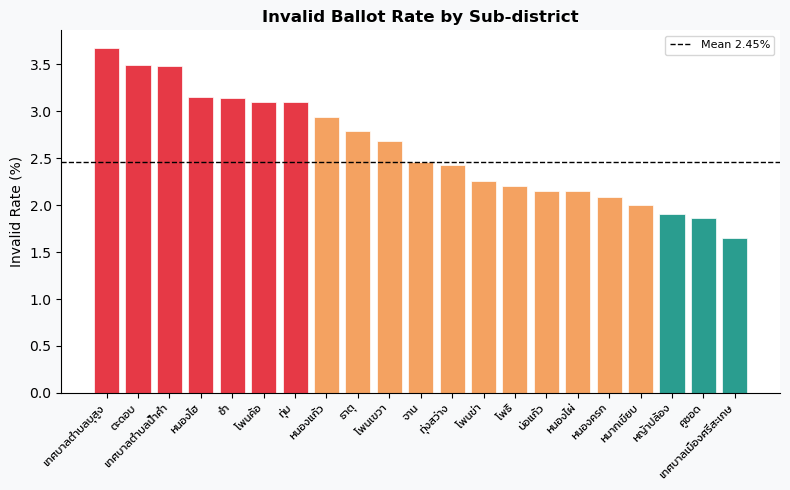

In [18]:
fig, ax1e = plt.subplots(figsize=(8, 5), facecolor="#F8F9FA")
tambon_invalid = df_const.groupby("ตำบลหน่วยเลือกตั้ง").apply(
    lambda g: g["bad_cards"].sum() / g["used_cards"].sum()
).sort_values(ascending=False)

bar_colors = ["#E63946" if v > 0.03 else "#F4A261" if v > 0.02 else "#2A9D8F" for v in tambon_invalid.values]
ax1e.bar(range(len(tambon_invalid)), tambon_invalid.values * 100, color=bar_colors, edgecolor="white", linewidth=0.5)

ax1e.set_title("Invalid Ballot Rate by Sub-district", fontweight="bold", fontsize=12)
ax1e.set_ylabel("Invalid Rate (%)", fontsize=10)
ax1e.set_xticks(range(len(tambon_invalid)))
# Apply Thai font ONLY to Tambon names
ax1e.set_xticklabels(tambon_invalid.index.tolist(), rotation=45, ha="right", fontproperties=THAI_FONT, fontsize=8)

avg_invalid = df_const["bad_cards"].sum() / df_const["used_cards"].sum() * 100
ax1e.axhline(avg_invalid, color="black", linestyle="--", linewidth=1, label=f"Mean {avg_invalid:.2f}%")
ax1e.legend(fontsize=8)
ax1e.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** 
- เทศบาลตำบลลบสูง (3.65%) and ตะดอบ (3.48%) are notably high invalid rate with almost 50% higher than the mean --> These are the same subdistricts showing low turnout

#### 6.1.5 Political Fragmentation (ENP) & Winner Distribution

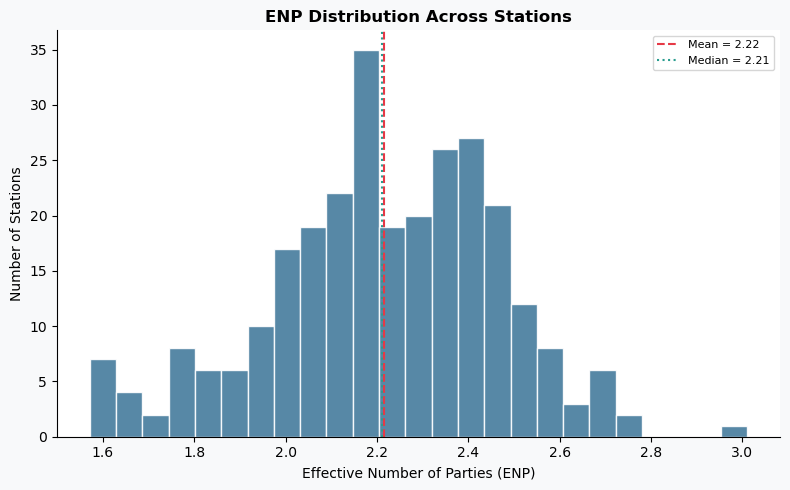

In [19]:
fig, ax1f = plt.subplots(figsize=(8, 5), facecolor="#F8F9FA")
enp_clean = df_const["ENP"].dropna()
ax1f.hist(enp_clean, bins=25, color="#457B9D", edgecolor="white", alpha=0.9)

ax1f.axvline(enp_clean.mean(), color="#E63946", linestyle="--", linewidth=1.5, label=f"Mean = {enp_clean.mean():.2f}")
ax1f.axvline(enp_clean.median(), color="#2A9D8F", linestyle=":", linewidth=1.5, label=f"Median = {enp_clean.median():.2f}")

ax1f.set_title("ENP Distribution Across Stations", fontweight="bold", fontsize=12)
ax1f.set_xlabel("Effective Number of Parties (ENP)", fontsize=10)
ax1f.set_ylabel("Number of Stations", fontsize=10)
ax1f.legend(fontsize=8)
ax1f.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

An ENP of 2.22 with mean ≈ median (2.21 vs 2.22) means the distribution is symmetric and the result is consistent: two candidates were effectively competing across nearly all stations, with the rest as noise. The slight right tail (some stations reaching ENP 2.8–3.0) indicates a handful of stations with more genuine three-way competition

#### 6.1.6 Candidate Heatmap

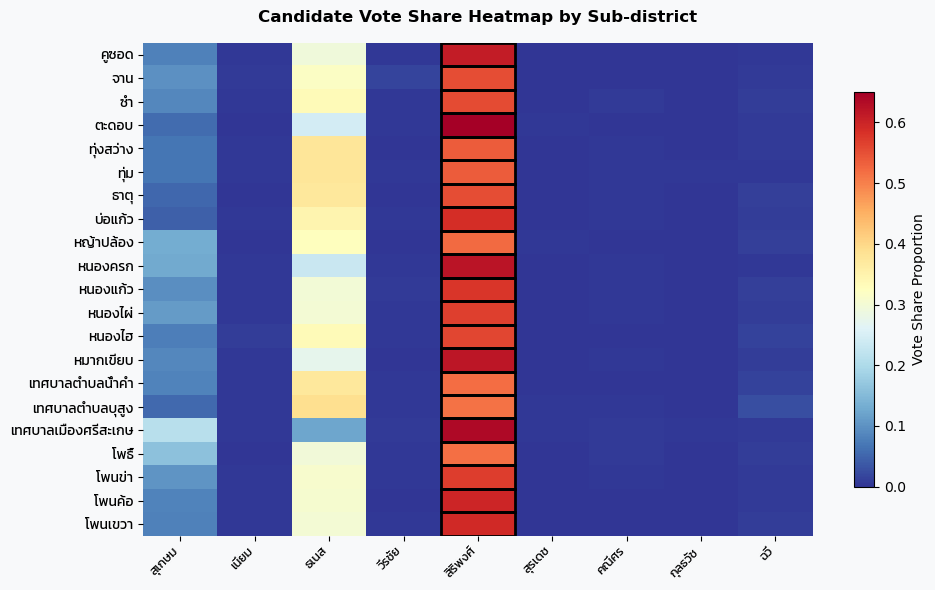

In [38]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#F8F9FA")

tambon_cand = df_const.groupby("ตำบลหน่วยเลือกตั้ง")[CANDIDATES].sum()
tambon_cand_share = tambon_cand.div(tambon_cand.sum(axis=1), axis=0)
tambon_cand_share.columns = [CAND_SHORT[c] for c in tambon_cand_share.columns]

hm = ax.imshow(tambon_cand_share.values, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=0.65)

ax.set_title("Candidate Vote Share Heatmap by Sub-district", fontweight="bold", fontsize=12, pad=15)

ax.set_xticks(range(len(tambon_cand_share.columns)))
ax.set_xticklabels(tambon_cand_share.columns.tolist(), rotation=45, ha="right", fontproperties=THAI_FONT, fontsize=9)

ax.set_yticks(range(len(tambon_cand_share)))
ax.set_yticklabels(tambon_cand_share.index.tolist(), fontproperties=THAI_FONT, fontsize=10)

cbar = plt.colorbar(hm, ax=ax, shrink=0.8)
cbar.set_label("Vote Share Proportion", fontsize=10)

for i in range(len(tambon_cand_share)):
    j = tambon_cand_share.values[i].argmax()
    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor="black", lw=2)) # highlight winner

ax.spines[["top","right","left","bottom"]].set_visible(False)
plt.tight_layout()
plt.show()

**Insights:**
- entire สิริพงศ์ column is a uniform deep red/orange across all 21 subdistrictsimplies he has no geographic weakness.
- สุเกษม has a light-blue presence in เทศบาลเมืองศรีสะเกษ and หญ้าปล้อง reflecting ประชาชน voter base in urban area

### 6.2 Party-List, Split-Ticket & Spatial Analysis
This section expands the analysis to the national Party-List vote (Form 5/18 บช), examining how local geography and party brand loyalty influenced voter behavior.

#### 6.2.1 Top Party-List Votes & Sub-district Distribution

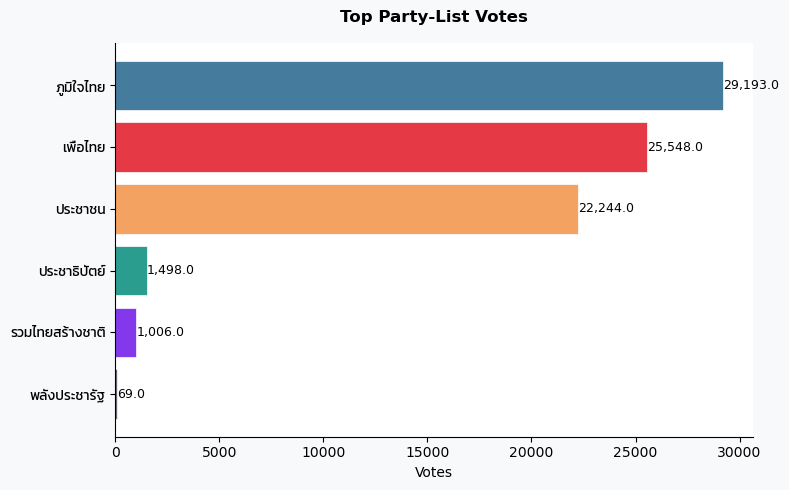

In [35]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="#F8F9FA")

pl_cols_present = [p for p in pl_cols if p in df_early_p.columns]
pl_combined = df_party[pl_cols].sum() + df_early_p[pl_cols_present].sum()
pl_combined = pl_combined.sort_values(ascending=False).head(8)

bar_c = [C.get(p, "#CED4DA") for p in pl_combined.index]
bars = ax.barh(range(len(pl_combined)), pl_combined.values[::-1], color=bar_c[::-1], edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, pl_combined.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, f"{val:,}", va="center", fontsize=9)

ax.set_title("Top Party-List Votes", fontweight="bold", fontsize=12, pad=15)
ax.set_xlabel("Votes", fontsize=10)

ax.set_yticks(range(len(pl_combined)))

ax.set_yticklabels(pl_combined.index.tolist()[::-1], fontproperties=THAI_FONT, fontsize=10)

ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Insights:**
- **Three-Party Race with a Clear Leader**: ภูมิใจไทย leads at 29,193 votes, but the gap to เพื่อไทย (25,548) and ประชาชน (22,244) is narrow (all three sit within a ~7,000 vote band)
- **Disconnect from the constituency result:** While it is observed thatt สิริพงศ์ won 93% of stations on the constituency ballot, his own party ภูมิใจไทย only captured ~37% of total party-list votes --> substantial portion of voters who chose สิริพงศ์ personally didn't give their party-list vote to ภูมิใจไทย.
- ประชาชน is competitive even though they have little presence in constituency --> This constituency has a hidden progressive voter base

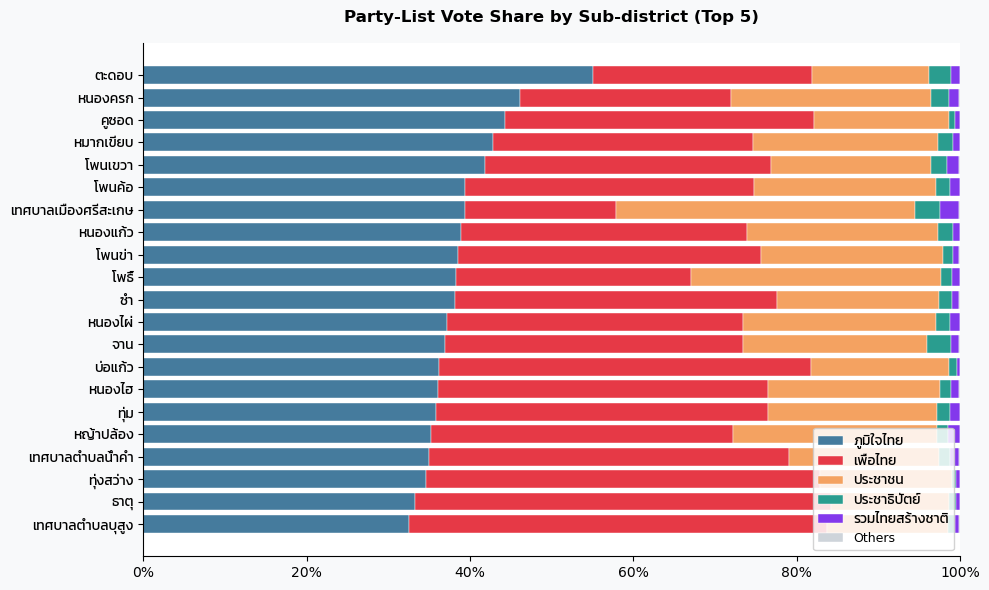

In [31]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#F8F9FA")

top5_parties = pl_combined.head(5).index.tolist()
tambon_pl = df_party.groupby("ตำบล")[top5_parties].sum()
tambon_pl["Others"] = df_party.groupby("ตำบล")[pl_cols].sum().sum(axis=1) - tambon_pl[top5_parties].sum(axis=1)
tambon_pl_share = tambon_pl.div(tambon_pl.sum(axis=1), axis=0)
tambon_pl_share = tambon_pl_share.sort_values(top5_parties[0], ascending=True)

bottom = np.zeros(len(tambon_pl_share))
stacked_colors = [C.get(p, "#CED4DA") for p in top5_parties] + ["#CED4DA"]

for col, color in zip(tambon_pl_share.columns, stacked_colors):
    vals = tambon_pl_share[col].values
    ax.barh(range(len(tambon_pl_share)), vals, left=bottom, label=col, color=color, edgecolor="white", linewidth=0.3)
    bottom += vals

ax.set_title("Party-List Vote Share by Sub-district (Top 5)", fontweight="bold", fontsize=12, pad=15)
ax.set_yticks(range(len(tambon_pl_share)))

ax.set_yticklabels(tambon_pl_share.index.tolist(), fontproperties=THAI_FONT, fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

leg = ax.legend(loc="lower right", fontsize=9, framealpha=0.85)
for text in leg.get_texts():
    if text.get_text() != "Others":
        text.set_fontproperties(THAI_FONT)

ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Insights:**
- ภูมิใจไทย dominant: ตะดอบ, หนองครก, คูซอด, หมากเขียบ all show shares in the 40–50% range. These are rural/peri-urban subdistricts where the incumbent party's network runs deep.
- เทศบาลตำบลบุสูง stands out as a clear outlier with ภูมิใจไทย share at lowest (30%) and เพื่อไทย significantly winning. This is likely an urban or semi-urban municipality where progressive parties perform structurally better.
- ประชาชน is consistently competing in every subdistrict. This suggests that the progressive vote is geographically distributed (suggesting ideological rather than local-network voting)
- Cross-reference with the heatmap: เทศบาลเมืองศรีสะเกษ shows a noticeably lighter blue for สุเกษม in the heatmap, consistent with this being an urban subdistrict where ประชาชน/เพื่อไทย voters also cross-voted for a different constituency candidate.

#### 6.2.2 The "Split-Ticket" Phenomenon by Sub-district

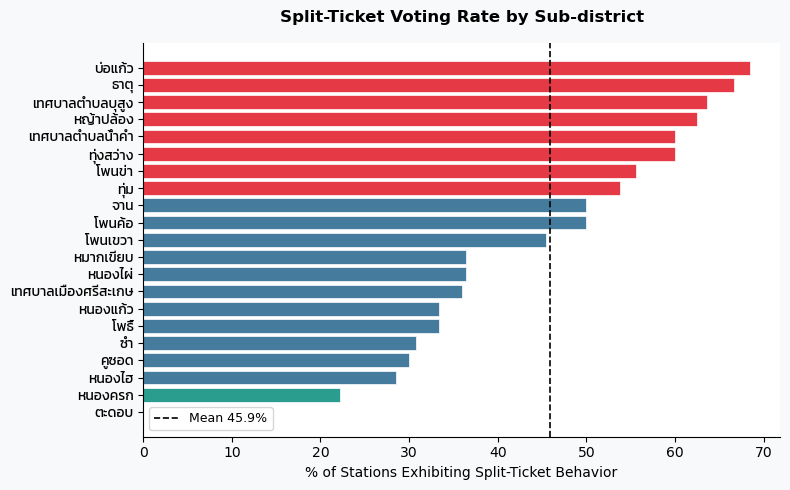

In [32]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="#F8F9FA")

split_by_tambon = df_merged.groupby("ตำบลหน่วยเลือกตั้ง")["split_ticket"].mean().sort_values(ascending=True)
bar_c2 = ["#E63946" if v > 0.5 else "#457B9D" if v > 0.25 else "#2A9D8F" for v in split_by_tambon.values]

ax.barh(range(len(split_by_tambon)), split_by_tambon.values * 100, color=bar_c2, edgecolor="white", linewidth=0.5)

mean_split = df_merged['split_ticket'].mean() * 100
ax.axvline(mean_split, color="black", linestyle="--", linewidth=1.2, label=f"Mean {mean_split:.1f}%")

ax.set_title("Split-Ticket Voting Rate by Sub-district", fontweight="bold", fontsize=12, pad=15)
ax.set_xlabel("% of Stations Exhibiting Split-Ticket Behavior", fontsize=10)
ax.set_yticks(range(len(split_by_tambon)))

ax.set_yticklabels(split_by_tambon.index.tolist(), fontproperties=THAI_FONT, fontsize=10)

ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

- **High split-ticket zone (red, >50%)**: บ่อแก้ว, ธาตุ, เทศบาลลบสูง, หญ้าปล้อง, ทุ่งสว่าง all exceed 60%. These are the วังหิน subdistricts. The split-ticket behaviour here likely reflects voters choosing สิริพงศ์ as their local MP (name recognition/service) while parking their party-list vote with เพื่อไทย or ประชาชน.
- **Low split-ticket zone (blue/green, <35%)**: หนองครก at just 22% is the most "aligned" subdistrict --> ภูมิใจไทย stronghold where partisan loyalty is intact.
- **ตะดอบ** has no bar visible: the same disengaged subdistrict from before

#### 6.2.3 Party-List Dominance Heatmap by Sub-district

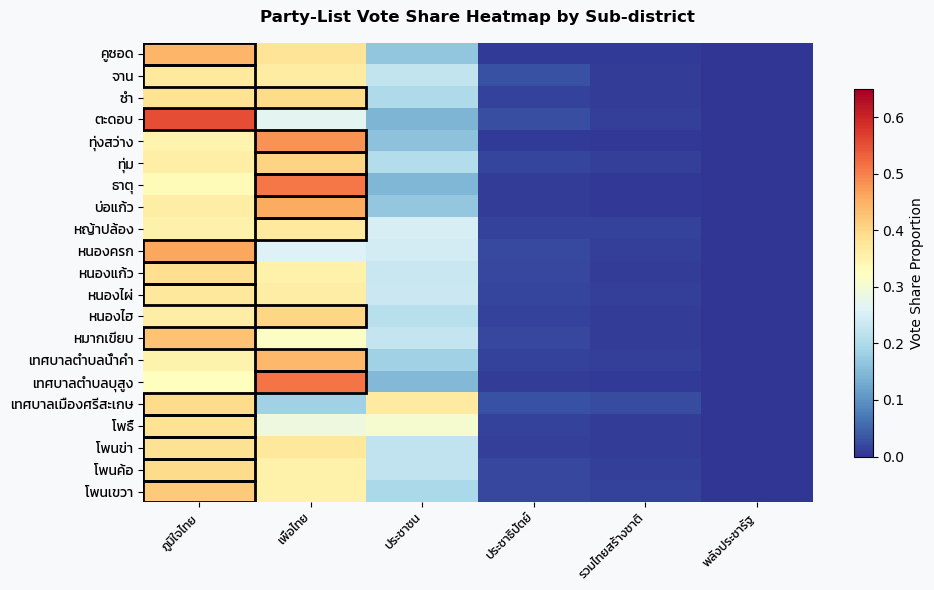

In [37]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor="#F8F9FA")

top_parties_hm = pl_combined.head(8).index.tolist()
tambon_pl_hm = df_party.groupby("ตำบล")[top_parties_hm].sum()
tambon_pl_share_hm = tambon_pl_hm.div(tambon_pl_hm.sum(axis=1), axis=0)

hm_pl = ax.imshow(tambon_pl_share_hm.values, aspect="auto", cmap="RdYlBu_r", vmin=0, vmax=0.65)

ax.set_title("Party-List Vote Share Heatmap by Sub-district", fontweight="bold", fontsize=12, pad=15)

ax.set_xticks(range(len(tambon_pl_share_hm.columns)))
ax.set_xticklabels(tambon_pl_share_hm.columns.tolist(), rotation=45, ha="right", fontproperties=THAI_FONT, fontsize=9)

ax.set_yticks(range(len(tambon_pl_share_hm)))
ax.set_yticklabels(tambon_pl_share_hm.index.tolist(), fontproperties=THAI_FONT, fontsize=10)

cbar_pl = plt.colorbar(hm_pl, ax=ax, shrink=0.8)
cbar_pl.set_label("Vote Share Proportion", fontsize=10)

for i in range(len(tambon_pl_share_hm)):
    j = tambon_pl_share_hm.values[i].argmax()
    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor="black", lw=2)) # highlight winner


ax.spines[["top","right","left","bottom"]].set_visible(False)
plt.tight_layout()
plt.show()

- ตะดอบ worth noticing (deep red on ภูมิใจไทย (0.6+)). its เพื่อไทย column is near-zero yellow and ประชาชน is faint. This is the same subdistrict that had the lowest turnout and highest invalid ballot rate. The voters who did show up voted overwhelmingly for one party
- The วังหิน subdistricts (ทุ่งสว่าง, ธาตุ, บ่อแก้ว, เทศบาลตำบลบุสูง) show the strongest เพื่อไทย signal. This aligns with high split-ticket rate found
- เทศบาลลบสูง is a mirror image of ตะดอบ: strong เพื่อไทย (second column dark), weaker ภูมิใจไทย --> urban municipality behaviour
- ประชาชน (third column) is uniformly light blue everywhere, indicating that their 22k votes spread across different consituency, which is the signature of an ideologically-driven party vote rather than a locally-networked one.

---

## 7. Unsupervised Learning (K-Means)
To move beyond descriptive statistics, we apply K-Means clustering to discover hidden behavioral patterns across the polling stations. Instead of grouping voters geographically, this algorithm groups stations based on how they vote.


### 7.1 Feature Selection & Scaling
Four key metrics are selected for a model: 
1. turnout rate
2. invalid ballot rate
3. winning margin
4. split-ticket voting flag

These features are standardized so the K-Means distance calculations treat all metrics equally.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# use rates and margins so stations of different sizes are comparable
cluster_features = ['turnout_rate', 'invalid_rate', 'margin', 'split_ticket_num' ]

df_merged['invalid_rate'] = df_merged['bad_cards'] / df_merged['show_up']
df_merged['split_ticket_num'] = df_merged['split_ticket'].astype(int)

df_model = df_merged[['source_pdf', 'ตำบลหน่วยเลือกตั้ง'] + cluster_features].dropna()

# Standardize data because K-Means is distance-based
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model[cluster_features])

### 7.2 Modelling

In [40]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_model['cluster_label'] = kmeans.fit_predict(scaled_data)

df_merged = df_merged.merge(df_model[['source_pdf', 'cluster_label']], on='source_pdf', how='left')

### 7.3 Cluster profiling & Insight

In [44]:
cluster_profiles = df_model.groupby('cluster_label')[cluster_features].mean()
print("\nCluster Profiles (Mean values per archetype):")
print(cluster_profiles.round(3))

cluster_names = {
    0: "Archetype A", 
    1: "Archetype B", 
    2: "Archetype C"
} 

if 'cluster_label' not in df_merged.columns:
    df_merged = df_merged.merge(
        df_model[['source_pdf', 'cluster_label']],
        on='source_pdf',
        how='left'
    )

df_merged['voter_archetype'] = df_merged['cluster_label'].map(cluster_names)


Cluster Profiles (Mean values per archetype):
               turnout_rate  invalid_rate  margin  split_ticket_num
cluster_label                                                      
0                     0.692         0.021   0.375             0.000
1                     0.707         0.018   0.243             0.988
2                     0.618         0.040   0.136             0.667


Cluster 0: "The Party Loyalists" (ภูมิใจไทย Strongholds & split_ticket = 0.000)
- These polling stations voted สิริพงศ์ and gave party-list to ภูมิใจไทย consistently.The local candidate likely won because of the party logo on their shirt, not necessarily their individual local campaign.
- Low invalid rate suggests voters are civically confident and politically clear on their choice

Cluster 1: "The Strategic Engaged" (Deliberate Splitters)
- Turnout 70.7% (highest), invalid rate 1.8% (lowest), solid margin (24.5%) and near-universal split ticket.
- These are highly politically active and highly educated/careful voters (best turnout, fewest wasted ballots). They almost universally split their votes (เลือกคนที่รัก เลือกพรรคที่ชอบ). 
- Sophisticated voter as they knew exactly which local candidate they wanted, and deliberately chose a different party for the national list.

Cluster 2: "The Disengaged" (Vulnerable Precincts)
- Lowest turnout (62.0%), highest invalid rate (4.0%), tightest margins (13.6%), mixed split-ticket (63.9%).
- Everything points to civic disengagement --> voter apathy is high (low turnout), and confusion is prevalent as their invalid ballot rate is roughly double the other clusters. 
- The narrow 13.6% margin suggests สิริพงศ์'s network is weakest here and ธเนส picks up more competitive ground

### 7.4 Voter Behaviour Segmentation: K-Means Clustering & Geographic Distribution of Archetypes

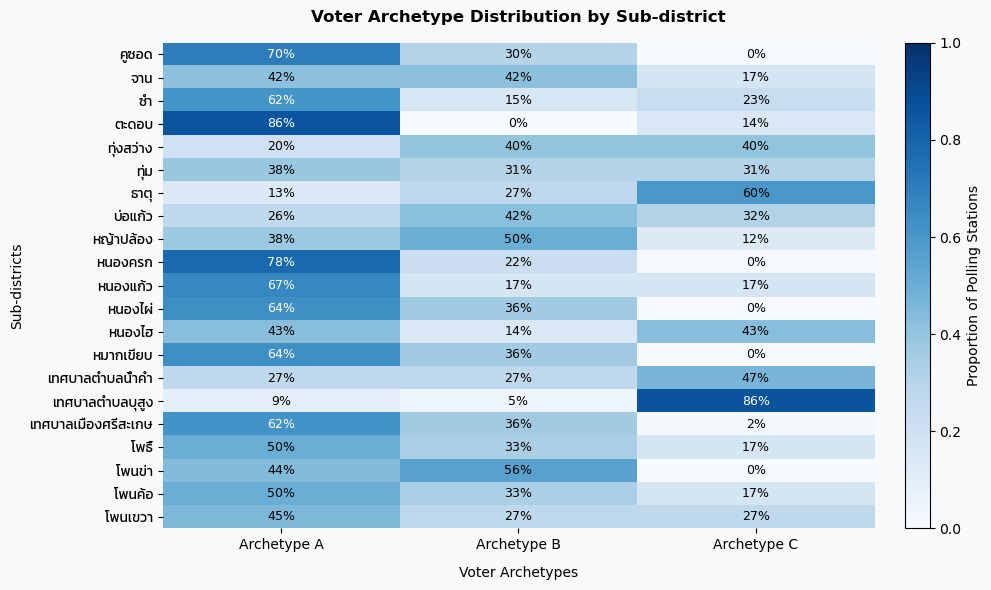

In [ ]:
# Create a cross-tabulation (pivot) of Sub-districts vs Archetypes
archetype_xtab = pd.crosstab(df_merged['ตำบลหน่วยเลือกตั้ง'], df_merged['voter_archetype'], normalize='index' )

if "Strategic Splitters" in archetype_xtab.columns:
    archetype_xtab = archetype_xtab.sort_values(by="Strategic Splitters", ascending=True)

# Plot
fig_hm, ax_hm = plt.subplots(figsize=(10, 6), facecolor="#F8F9FA")

cax = ax_hm.imshow(archetype_xtab.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)

ax_hm.set_xticks(range(len(archetype_xtab.columns)))
ax_hm.set_xticklabels(archetype_xtab.columns, fontsize=10)

ax_hm.set_yticks(range(len(archetype_xtab.index)))
ax_hm.set_yticklabels(archetype_xtab.index, fontproperties=THAI_FONT, fontsize=10)

# Add percentage text annotations inside the heatmap cells 
for i in range(len(archetype_xtab.index)):
    for j in range(len(archetype_xtab.columns)):
        val = archetype_xtab.values[i, j]
        text_color = "white" if val > 0.6 else "black"
        ax_hm.text(j, i, f"{val:.0%}", ha="center", va="center", 
                   color=text_color, fontsize=9)

ax_hm.set_title("Voter Archetype Distribution by Sub-district", fontweight="bold", fontsize=12, pad=15)
ax_hm.set_xlabel("Voter Archetypes", fontsize=10, labelpad=10)
ax_hm.set_ylabel("Sub-districts", fontsize=10)

ax_hm.spines[["top", "right", "left", "bottom"]].set_visible(False)

cbar = plt.colorbar(cax, ax=ax_hm, fraction=0.046, pad=0.04)
cbar.set_label("Proportion of Polling Stations", fontsize=10)

plt.tight_layout()
plt.show()

- เทศบาลลบสูง (86% Archetype C — Disengaged): This is the only subdistrict where Archetype C almost completely dominates. This subdistrict is structurally the most politically distinct place in your entire constituency (high split-ticket, strong เพื่อไทย lean, low ภูมิใจไทย share).
- ธาตุ (60% Archetype C) is the second most disengaged subdistrict by this measure, and it's in วังหิน  (consistent with the high split-ticket rates). The disengagement and the split-ticket behaviour co-exist, which suggests voters there are present but not committed to any party.
- ตะดอบ (86% Archetype A) 86% Loyal Core. The resolution is that Archetype A captures the margin and split-ticket dimensions, not invalid rate directly. The voters who did show up voted aligned — but many didn't show up at all. 